# Predicting Road Accident Risk
Playground Series - Season 5, Episode 10

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
# Libraries for data preprocessing and visualization
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer

import optuna
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

In [110]:
# Prepare libraries for Deep Learning models with Pytorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torchvision.transforms as transforms
import torchvision.models as models

In [111]:
# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f'Using device: {device}')

Using device: cuda


## Data Loading

In [112]:
df_train = pd.read_csv('C:\\Users\\Blix\\Documents\\GitHub\\ml-development\\kaggle\\Playground_Predicting Road Accident Risk\\train.csv')
df_test = pd.read_csv('C:\\Users\\Blix\\Documents\\GitHub\\ml-development\\kaggle\\Playground_Predicting Road Accident Risk\\test.csv')
df_sample_submission = pd.read_csv('C:\\Users\\Blix\\Documents\\GitHub\\ml-development\\kaggle\\Playground_Predicting Road Accident Risk\\sample_submission.csv')

In [113]:
df_train.head()

,id,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
0,0,urban,2,0.06,35,daylight,rainy,False,True,afternoon,False,True,1,0.13
1,1,urban,4,0.99,35,daylight,clear,True,False,evening,True,True,0,0.35
2,2,rural,4,0.63,70,dim,clear,False,True,morning,True,False,2,0.30
3,3,highway,4,0.07,35,dim,rainy,True,True,morning,False,False,1,0.21
4,4,rural,1,0.58,60,daylight,foggy,False,False,evening,True,False,1,0.56


In [114]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517754 entries, 0 to 517753
Data columns (total 14 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      517754 non-null  int64  
 1   road_type               517754 non-null  object 
 2   num_lanes               517754 non-null  int64  
 3   curvature               517754 non-null  float64
 4   speed_limit             517754 non-null  int64  
 5   lighting                517754 non-null  object 
 6   weather                 517754 non-null  object 
 7   road_signs_present      517754 non-null  bool   
 8   public_road             517754 non-null  bool   
 9   time_of_day             517754 non-null  object 
 10  holiday                 517754 non-null  bool   
 11  school_season           517754 non-null  bool   
 12  num_reported_accidents  517754 non-null  int64  
 13  accident_risk           517754 non-null  float64
dtypes: bool(4), float64(

In [115]:
df_train.duplicated().sum()

np.int64(0)

In [116]:
df_train.isna().sum()

id                        0
road_type                 0
num_lanes                 0
curvature                 0
speed_limit               0
lighting                  0
weather                   0
road_signs_present        0
public_road               0
time_of_day               0
holiday                   0
school_season             0
num_reported_accidents    0
accident_risk             0
dtype: int64

In [117]:
# Check number of unique values in each column
df_train.nunique()

id                        517754
road_type                      3
num_lanes                      4
curvature                    261
speed_limit                    5
lighting                       3
weather                        3
road_signs_present             2
public_road                    2
time_of_day                    3
holiday                        2
school_season                  2
num_reported_accidents         8
accident_risk                 98
dtype: int64

## Data Cleaning

In [118]:
# Label encoding for categorical features
df_train.drop(columns=['id'], inplace=True)
categorical_cols = df_train.select_dtypes(include=['object']).columns
numerical_cols = df_train.select_dtypes(include=['int64', 'float64']).columns
# Remove accident_risk in numerical_cols
numerical_cols = numerical_cols.drop('accident_risk')

In [119]:
# Create duplicate of dataframe to preserve original data
df_train_processed = df_train.copy()
df_test_processed = df_test.copy()

## Exploratory Data Analysis

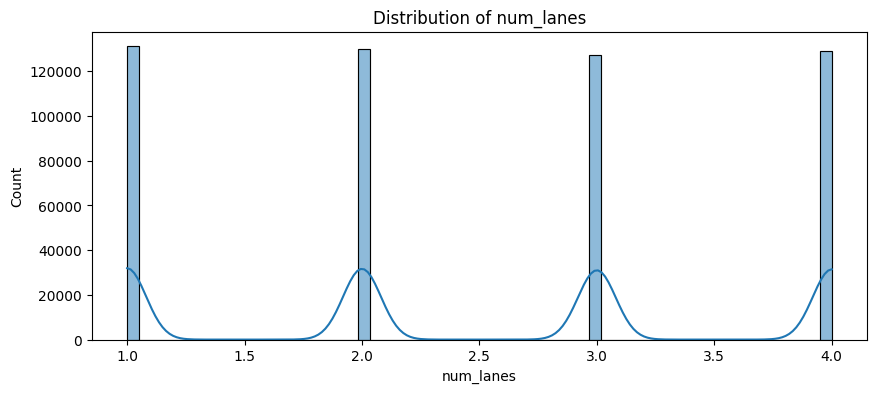

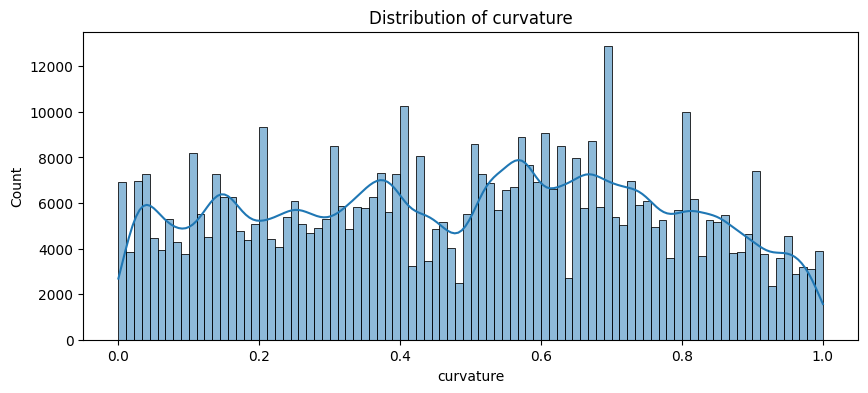

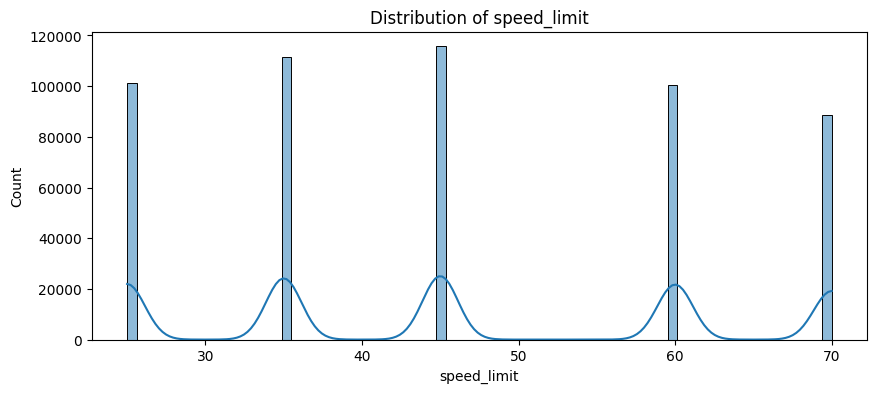

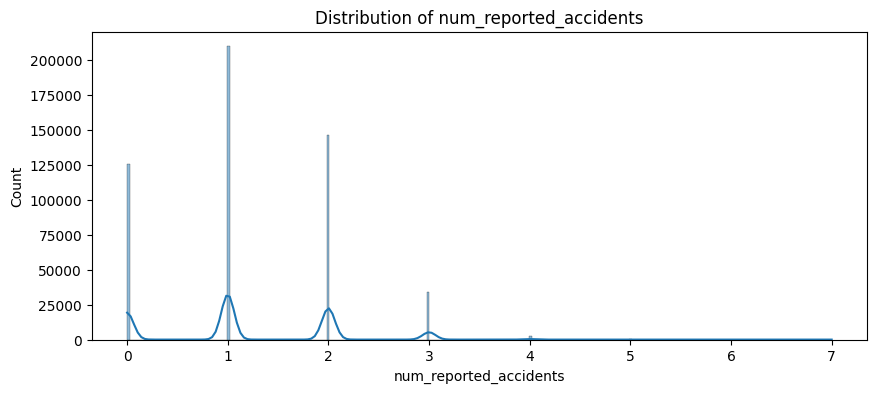

In [120]:
# Visualize the distribution of numerical features
for col in numerical_cols:
    plt.figure(figsize=(10, 4))
    sns.histplot(df_train_processed[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

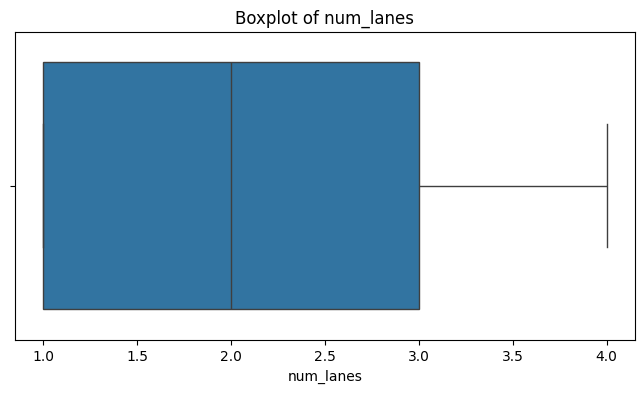

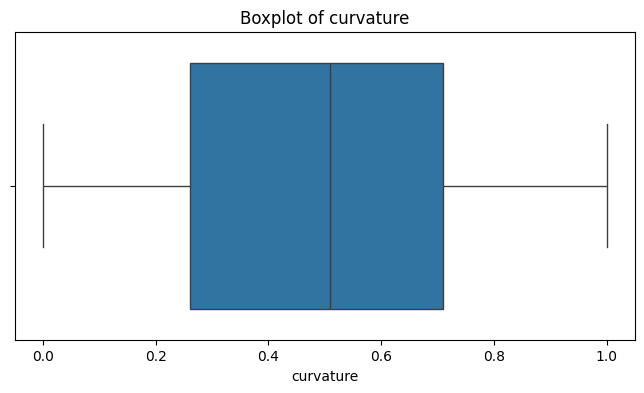

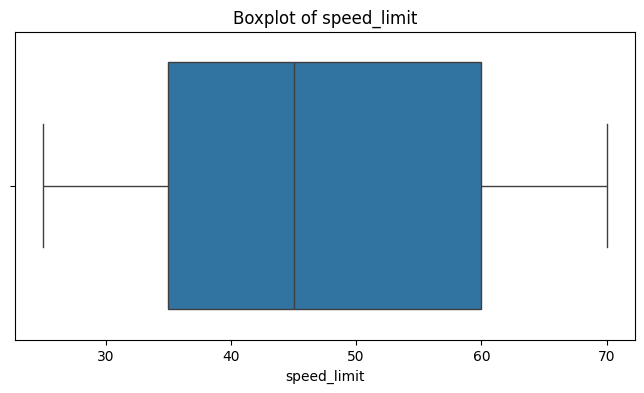

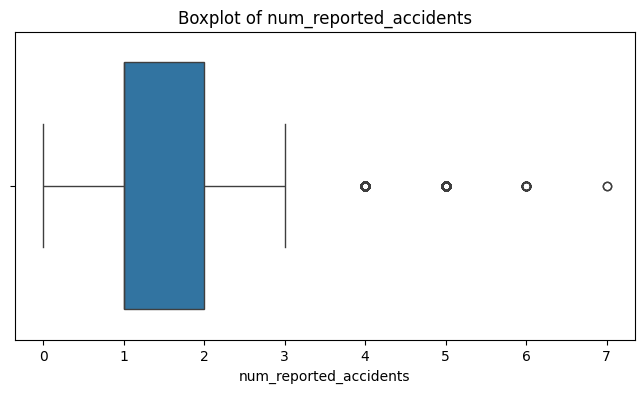

In [121]:
# Use boxplot to identify outliers in numerical features
for col in numerical_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df_train_processed[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

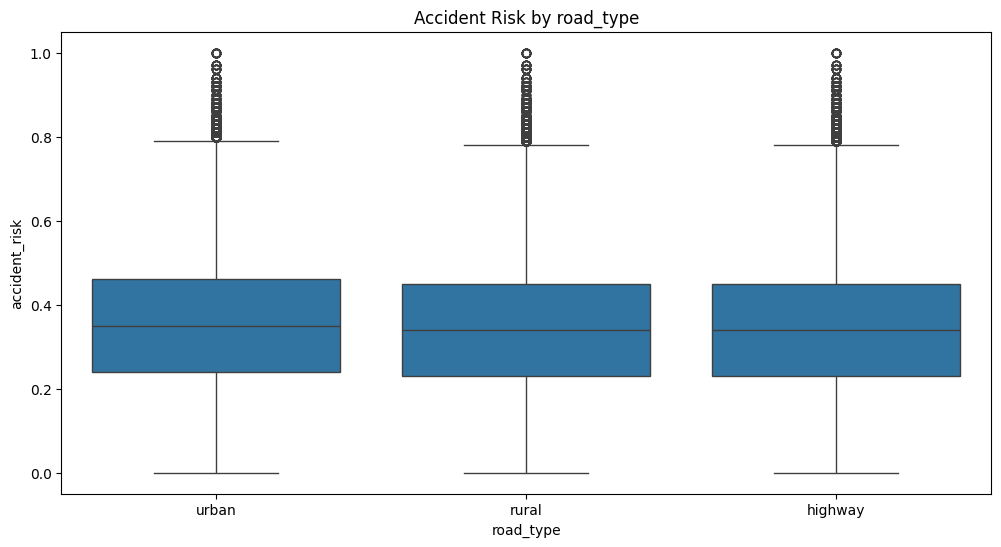

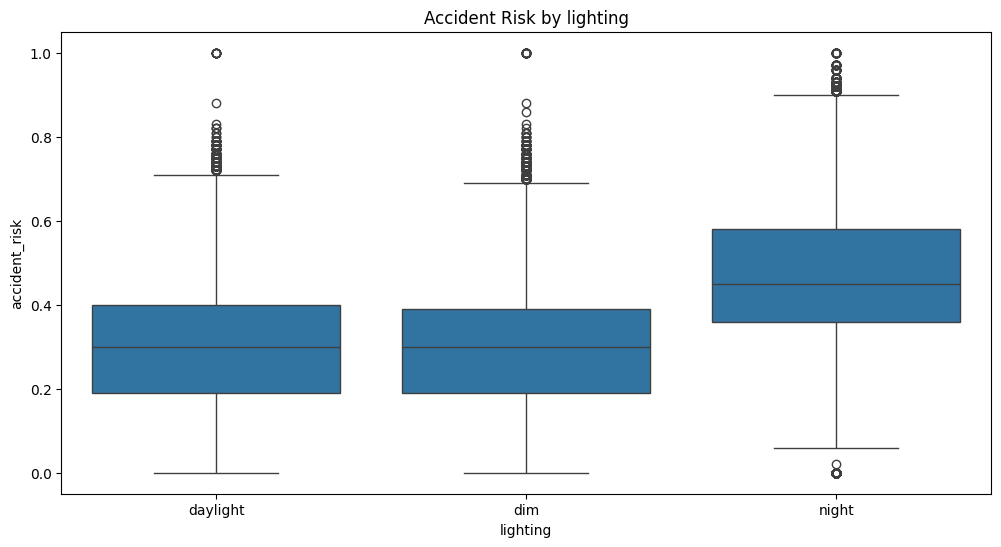

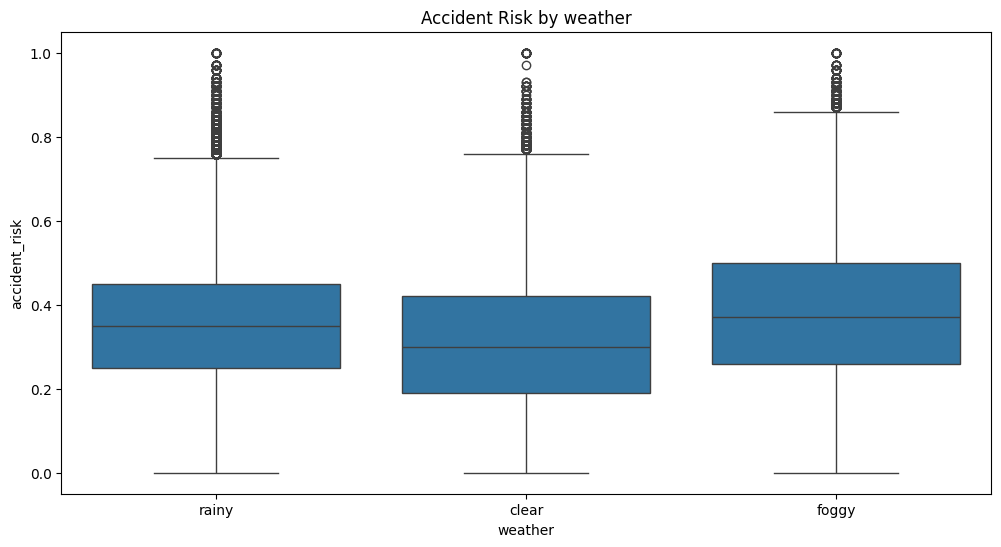

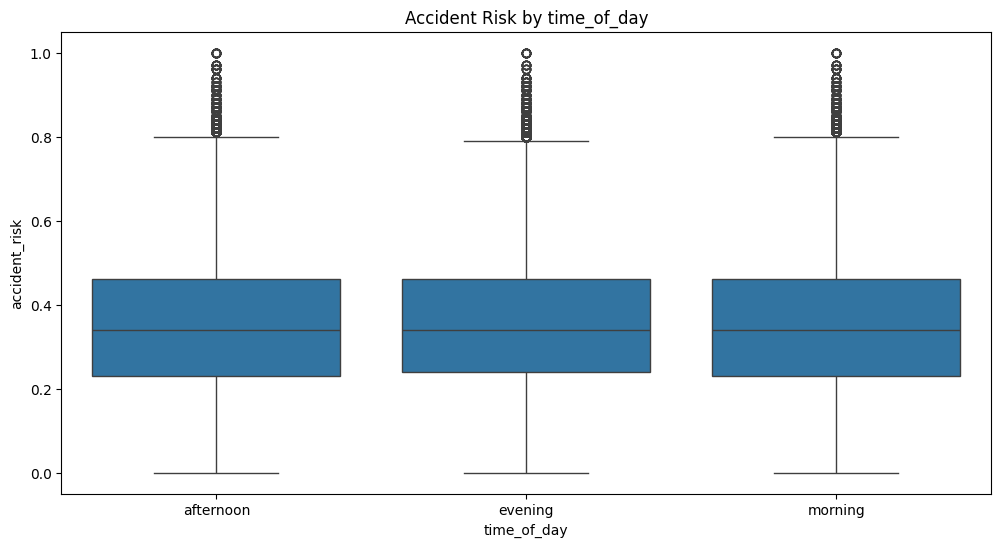

In [122]:
# Check distribution of accident risk based on categorical features
for col in categorical_cols:
    plt.figure(figsize=(12, 6))
    sns.boxplot(x=df_train_processed[col], y=df_train_processed['accident_risk'])
    plt.title(f'Accident Risk by {col}')
    plt.show()

## Feature Engineering

In [123]:
# Convert categorical columns using LabelEncoder
lbl = LabelEncoder()
for col in categorical_cols:
    df_train_processed[col] = lbl.fit_transform(df_train_processed[col])
    df_test_processed[col] = lbl.transform(df_test_processed[col])

In [124]:
# Convert bool columns to integers
bool_cols = df_train_processed.select_dtypes(include=['bool']).columns
for col in bool_cols:
    df_train_processed[col] = df_train_processed[col].astype(int)
    df_test_processed[col] = df_test_processed[col].astype(int)

In [125]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517754 entries, 0 to 517753
Data columns (total 13 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   road_type               517754 non-null  object 
 1   num_lanes               517754 non-null  int64  
 2   curvature               517754 non-null  float64
 3   speed_limit             517754 non-null  int64  
 4   lighting                517754 non-null  object 
 5   weather                 517754 non-null  object 
 6   road_signs_present      517754 non-null  bool   
 7   public_road             517754 non-null  bool   
 8   time_of_day             517754 non-null  object 
 9   holiday                 517754 non-null  bool   
 10  school_season           517754 non-null  bool   
 11  num_reported_accidents  517754 non-null  int64  
 12  accident_risk           517754 non-null  float64
dtypes: bool(4), float64(2), int64(3), object(4)
memory usage: 37.5+ MB


In [126]:
# Perform Standard Scaling on numerical features
scaler = StandardScaler()
df_train_processed[numerical_cols] = scaler.fit_transform(df_train_processed[numerical_cols])
df_test_processed[numerical_cols] = scaler.transform(df_test_processed[numerical_cols])


## Train-Test-Split

In [127]:
# Perform 80-20 train-test split
X = df_train_processed.drop(columns=['accident_risk'])
y = df_train_processed['accident_risk']

In [128]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

## Model Training

In [ ]:
# Train using RandomForestRegressor and XGBRegressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [132]:
xgb_model = XGBRegressor(n_estimators=100, random_state=42)
xgb_model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


## Model Evaluation

In [ ]:
# Check test set predictions
rf_test_preds = rf_model.predict(X_val)
xgb_test_preds = xgb_model.predict(X_val)

In [ ]:
# Check RMSE on validation set
rf_rmse = np.sqrt(mean_squared_error(y_val, rf_test_preds))
xgb_rmse = np.sqrt(mean_squared_error(y_val, xgb_test_preds))
print(f'Random Forest RMSE: {rf_rmse}')
print(f'XGBoost RMSE: {xgb_rmse}')

Random Forest RMSE: 0.05953371168248084
XGBoost RMSE: 0.056297349469026384


## Hyperparameter Tuning

In [157]:
import xgboost as xgb

In [168]:
# Import optuna for hyperparameter tuning using XGBRegressor and early stopping
def objective(trial):
    params = {
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 0, 2.0),
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000, step=100),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "max_delta_step": trial.suggest_int("max_delta_step", 0, 5),
        "subsample": trial.suggest_float("subsample", 0.6, 0.9, step=0.05),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 0.9, step=0.05),
        "colsample_bylevel": trial.suggest_float("colsample_bylevel", 0.6, 0.9, step=0.05),
        "colsample_bynode": trial.suggest_float("colsample_bynode", 0.6, 0.9, step=0.05),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 1.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-2, 5.0, log=True),
        "objective": "reg:squarederror",
        "eval_metric": "mae",
        "random_state": 42,
        "tree_method": "hist",
    }

    dtrain = xgb.DMatrix(X_train, label=y_train)
    dval = xgb.DMatrix(X_val, label=y_val)
    early_stopping_rounds = trial.suggest_int("early_stopping_rounds", 50, 200, step=25)
    pruning_callback = optuna.integration.XGBoostPruningCallback(trial, "validation-mae")

    model = xgb.train(
        params=params,
        dtrain=dtrain,
        evals=[(dval, 'validation')],
        num_boost_round=params['n_estimators'],
        early_stopping_rounds=early_stopping_rounds,
        verbose_eval=False,
        callbacks=[pruning_callback]
    )

    preds = model.predict(dval)
    rmse = np.sqrt(mean_squared_error(y_val, preds))
    return rmse


In [169]:
# Remove user warnings
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [170]:
# Run optuna study
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=2000)
best_params = study.best_params
print("Best parameters:", best_params)


[I 2025-10-30 20:49:47,557] A new study created in memory with name: no-name-6c8dee8f-9c07-4de1-a357-357c382030c2
[I 2025-10-30 20:49:48,261] Trial 0 finished with value: 0.05713336561705475 and parameters: {'max_depth': 5, 'min_child_weight': 1, 'gamma': 1.3362898411720234, 'n_estimators': 600, 'learning_rate': 0.1629858309749362, 'max_delta_step': 4, 'subsample': 0.75, 'colsample_bytree': 0.7, 'colsample_bylevel': 0.9, 'colsample_bynode': 0.9, 'reg_alpha': 0.2666531931115522, 'reg_lambda': 0.016545557916945376, 'early_stopping_rounds': 50}. Best is trial 0 with value: 0.05713336561705475.
[I 2025-10-30 20:49:49,307] Trial 1 finished with value: 0.05708867270012644 and parameters: {'max_depth': 6, 'min_child_weight': 4, 'gamma': 0.2809751786401764, 'n_estimators': 300, 'learning_rate': 0.06148100718121472, 'max_delta_step': 4, 'subsample': 0.7, 'colsample_bytree': 0.7, 'colsample_bylevel': 0.7, 'colsample_bynode': 0.65, 'reg_alpha': 0.6718548130906159, 'reg_lambda': 1.629184420998216,

Best parameters: {'max_depth': 8, 'min_child_weight': 4, 'gamma': 0.010919001979127735, 'n_estimators': 500, 'learning_rate': 0.1894890516721248, 'max_delta_step': 3, 'subsample': 0.8, 'colsample_bytree': 0.85, 'colsample_bylevel': 0.9, 'colsample_bynode': 0.9, 'reg_alpha': 0.034861872204296374, 'reg_lambda': 0.22601658482260242, 'early_stopping_rounds': 150}


## Tuned Model

In [171]:
# Use best parameters to train final XGBRegressor model with early stopping
dtrain = xgb.DMatrix(X_train, label=y_train)
dval = xgb.DMatrix(X_val, label=y_val)
early_stopping_rounds = best_params.get("early_stopping_rounds", 100)

model = xgb.train(
    params=best_params,
    dtrain=dtrain,
    evals=[(dval, 'validation')],
    num_boost_round=best_params['n_estimators'],
    early_stopping_rounds=early_stopping_rounds,
    verbose_eval=True
)

[0]	validation-rmse:0.14747
[1]	validation-rmse:0.12408
[2]	validation-rmse:0.10723
[3]	validation-rmse:0.09328
[4]	validation-rmse:0.08255
[5]	validation-rmse:0.07637
[6]	validation-rmse:0.07161
[7]	validation-rmse:0.06680
[8]	validation-rmse:0.06341
[9]	validation-rmse:0.06112
[10]	validation-rmse:0.06001
[11]	validation-rmse:0.05915
[12]	validation-rmse:0.05828
[13]	validation-rmse:0.05760
[14]	validation-rmse:0.05715
[15]	validation-rmse:0.05694
[16]	validation-rmse:0.05677
[17]	validation-rmse:0.05673
[18]	validation-rmse:0.05658
[19]	validation-rmse:0.05647
[20]	validation-rmse:0.05640
[21]	validation-rmse:0.05634
[22]	validation-rmse:0.05632
[23]	validation-rmse:0.05629
[24]	validation-rmse:0.05627
[25]	validation-rmse:0.05626
[26]	validation-rmse:0.05625
[27]	validation-rmse:0.05625
[28]	validation-rmse:0.05624
[29]	validation-rmse:0.05623
[30]	validation-rmse:0.05623
[31]	validation-rmse:0.05623
[32]	validation-rmse:0.05622
[33]	validation-rmse:0.05622
[34]	validation-rmse:0.0

In [172]:
# predict on test set of best model
xgb_test_preds = model.predict(dval)
# Check RMSE on validation set
xgb_rmse = np.sqrt(mean_squared_error(y_val, xgb_test_preds))
print(f'XGBoost RMSE: {xgb_rmse}')

XGBoost RMSE: 0.056202048792543056


## Submission File Creation

In [141]:
# Create submission file for RandomForestRegressor
rf_submission_preds = rf_model.predict(df_test_processed.drop(columns=['id']))
submission_rf = pd.DataFrame({
    'id': df_test['id'],
    'accident_risk': rf_submission_preds
})

In [142]:
# export to csv
submission_rf.to_csv('rf_submission.csv', index=False)

In [143]:
# Create submission file for XGBRegressor
xgb_submission_preds = xgb_model.predict(df_test_processed.drop(columns=['id']))
submission_xgb = pd.DataFrame({
    'id': df_test['id'],
    'accident_risk': xgb_submission_preds
})

In [144]:
# Export to csv
submission_xgb.to_csv('xgb_submission.csv', index=False)

In [173]:
# Create submission file for Tuned XGBRegressor
tuned_xgb_submission_preds = model.predict(xgb.DMatrix(df_test_processed.drop(columns=['id'])))
submission_tuned_xgb = pd.DataFrame({
    'id': df_test['id'],
    'accident_risk': tuned_xgb_submission_preds
})


In [174]:
# Export to csv
submission_tuned_xgb.to_csv('tuned_xgb_submission.csv', index=False)